Device: cuda
Monument vector geometry breakdown:
Polygon    1182
Name: count, dtype: int64
Scanning dataset folders...

--- Running Alignment Diagnostic (20 site patches) ---
Empty Mask Rate: 0/20 (0.0%)
✓ Alignment check passed: Monument geometries successfully rasterized.

  Training (MobileNetV3-Small) w/ 8-Channel NIR+LiDAR | Epochs 20
Ep 01/20 | LR: 1.99e-04  ✓ saved  | no_improve: 0/5
  Train -> Tot Loss: 0.1441 | Cls Loss: 0.0943 | AUC: 0.5380 | F1: 0.5275
  Test  -> Tot Loss: 0.1376 | Cls Loss: 0.0962 | AUC: 0.5712 | F1: 0.4510
Ep 02/20 | LR: 1.95e-04  ✓ saved  | no_improve: 0/5
  Train -> Tot Loss: 0.1298 | Cls Loss: 0.0910 | AUC: 0.5722 | F1: 0.5549
  Test  -> Tot Loss: 0.1296 | Cls Loss: 0.0980 | AUC: 0.6035 | F1: 0.4561
Ep 03/20 | LR: 1.89e-04  ✓ saved  | no_improve: 0/5
  Train -> Tot Loss: 0.1187 | Cls Loss: 0.0866 | AUC: 0.6209 | F1: 0.5568
  Test  -> Tot Loss: 0.1207 | Cls Loss: 0.0947 | AUC: 0.6455 | F1: 0.4913
Ep 04/20 | LR: 1.81e-04  ✓ saved  | no_improve: 0/5
  Trai

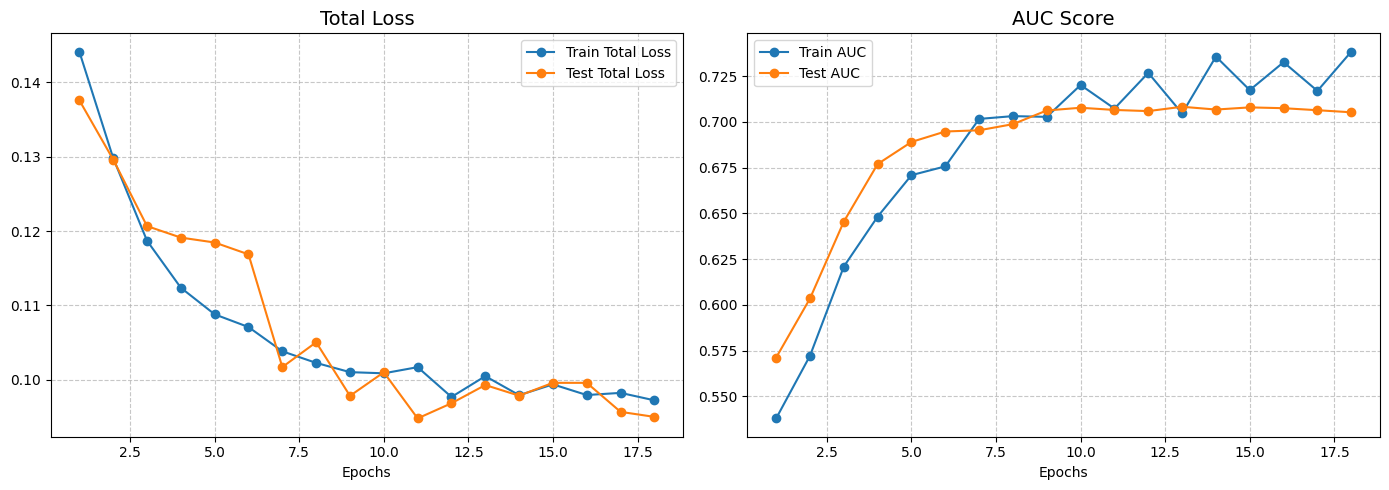

In [2]:
# !pip install -q rasterio geopandas shapely pyproj
import os, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
import torchvision.models as models
import torchvision.transforms.functional as TF
from sklearn.metrics import roc_auc_score, f1_score

import rasterio
from rasterio.features import rasterize
import geopandas as gpd
import pyproj
from shapely.geometry import box

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

torch.backends.cudnn.benchmark = True

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════════════════
class CFG:
    ROOT                 = Path('/kaggle/input/datasets/shreyansdeshpande/2nd-variation/FINALCNNDATA_NEW_01')
    OUTPUT_DIR           = Path('/kaggle/working')
    MONUMENT_VECTOR_PATH = Path('/kaggle/input/datasets/shreyansdeshpande/monuments/monuments_inside_valid_dtm.gpkg')
    
    TRAIN_SITE    = ROOT / 'train' / 'site'
    TRAIN_NOSITE  = ROOT / 'train' / 'no_site'
    VAL_SITE      = ROOT / 'validation' / 'site'
    VAL_NOSITE    = ROOT / 'validation' / 'no_site'
    TEST_SITE     = ROOT / 'test' / 'site'
    TEST_NOSITE   = ROOT / 'test' / 'no_site'
    
    IMG_SUFFIX    = '.tif'
    
    # Indices 3–10 (8 channels): NIR, SVF, LRM, Slope, HS0, HS1, HS2, HS3
    LIDAR_BANDS   = list(range(3, 11))   
    NUM_LIDAR_CH  = 8                        

    NUM_CLASSES       = 1
    PRETRAINED        = True
    FREEZE_BACKBONES  = True  
    
    USE_MIXUP         = False        # Disabled to protect terrain geometry and binary mask edges
    MIXUP_ALPHA       = 0.3
    
    DROPOUT           = 0.5          
    LR                = 2e-4         
    WEIGHT_DECAY      = 2e-3         
    MASK_WEIGHT       = 0.1          

    IMG_SIZE     = 224
    BATCH_SIZE   = 32
    NUM_EPOCHS   = 20
    PATIENCE     = 5
    SEED         = 42
    NUM_WORKERS  = 4
    USE_AMP      = True              

    T_MAX   = NUM_EPOCHS
    ETA_MIN = 1e-6

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG.SEED)
CFG.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
# VECTOR FILE INITIALIZATION & BUFFERING
# ══════════════════════════════════════════════════════════════════════════════
if not CFG.MONUMENT_VECTOR_PATH.exists():
    raise FileNotFoundError(f"Monument vector file not found at: {CFG.MONUMENT_VECTOR_PATH}")

monuments_gdf = gpd.read_file(CFG.MONUMENT_VECTOR_PATH)
if monuments_gdf.crs is None:
    raise ValueError(f"Vector dataset {CFG.MONUMENT_VECTOR_PATH} has no embedded CRS defined.")

print("Monument vector geometry breakdown:")
print(monuments_gdf.geometry.geom_type.value_counts())

is_point_geom = monuments_gdf.geometry.geom_type.isin(['Point', 'MultiPoint'])
if is_point_geom.any():
    monuments_gdf.loc[is_point_geom, 'geometry'] = monuments_gdf.loc[is_point_geom, 'geometry'].buffer(15)
    print(f"Buffered {is_point_geom.sum()} point features by 15 meters.")

_CRS_CACHE = {}

def get_reprojected_monuments(target_crs):
    target_pyproj = pyproj.CRS.from_user_input(target_crs)
    gdf_pyproj = monuments_gdf.crs if isinstance(monuments_gdf.crs, pyproj.CRS) else pyproj.CRS.from_user_input(monuments_gdf.crs)

    target_epsg = target_pyproj.to_epsg()
    gdf_epsg = gdf_pyproj.to_epsg()

    if target_epsg is not None and gdf_epsg is not None:
        is_same_crs = (target_epsg == gdf_epsg)
    else:
        is_same_crs = (target_pyproj.to_wkt() == gdf_pyproj.to_wkt())

    crs_key = target_pyproj.to_string()
    if crs_key not in _CRS_CACHE:
        if is_same_crs:
            reproj = monuments_gdf
        else:
            reproj = monuments_gdf.to_crs(target_pyproj)
        _CRS_CACHE[crs_key] = (reproj, reproj.sindex)
    return _CRS_CACHE[crs_key]

# ══════════════════════════════════════════════════════════════════════════════
# LOSS FUNCTIONS (LABEL-SMOOTHED FOCAL + AUXILIARY MASK LOSS)
# ══════════════════════════════════════════════════════════════════════════════
class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.5, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ls    = label_smoothing
        self.bce   = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        targets = targets * (1.0 - self.ls) + 0.5 * self.ls
        bce_loss = self.bce(inputs, targets)
        pt = torch.exp(-bce_loss)
        alpha_t = self.alpha * targets + (1.0 - self.alpha) * (1.0 - targets)
        return (alpha_t * (1.0 - pt) ** self.gamma * bce_loss).mean()

focal_criterion = BinaryFocalLoss(alpha=0.5, gamma=2.0, label_smoothing=0.1)
mask_criterion  = nn.BCEWithLogitsLoss()

def combined_loss(class_logits, mask_logits, class_targets, mask_targets):
    cls_loss = focal_criterion(class_logits, class_targets)
    
    b, c, h, w = mask_logits.shape
    mask_targets_down = F.interpolate(
        mask_targets.unsqueeze(1), 
        size=(h, w), 
        mode='bilinear', 
        align_corners=False
    )
    
    msk_loss = mask_criterion(mask_logits, mask_targets_down)
    total_loss = cls_loss + (CFG.MASK_WEIGHT * msk_loss)
    return total_loss, cls_loss, msk_loss

# ══════════════════════════════════════════════════════════════════════════════
# BUILD DATAFRAMES
# ══════════════════════════════════════════════════════════════════════════════
def folder_to_df(site_dir: Path, nosite_dir: Path) -> pd.DataFrame:
    rows = []
    for label, folder in [(1, site_dir), (0, nosite_dir)]:
        files = list(folder.glob(f'*{CFG.IMG_SUFFIX}'))
        for f in sorted(files):
            rows.append({'filepath': str(f), 'label': label})
    return pd.DataFrame(rows, columns=['filepath', 'label'])

print('Scanning dataset folders...')
train_df = folder_to_df(CFG.TRAIN_SITE,  CFG.TRAIN_NOSITE)
val_df   = folder_to_df(CFG.VAL_SITE,    CFG.VAL_NOSITE)
test_df  = folder_to_df(CFG.TEST_SITE,   CFG.TEST_NOSITE)

if len(train_df) == 0: 
    raise FileNotFoundError("Training DataFrame is empty!")

# ══════════════════════════════════════════════════════════════════════════════
# DATASET & VECTOR MASK GENERATOR
# ══════════════════════════════════════════════════════════════════════════════
def per_channel_normalize(arr: np.ndarray) -> np.ndarray:
    mean = arr.mean(axis=(1, 2), keepdims=True)
    std = arr.std(axis=(1, 2), keepdims=True)
    std = np.where(std < 1e-3, 1.0, std)
    return (arr - mean) / (std + 1e-6)

def load_patch_and_mask(tif_path: str, label: int, warn_empty: bool = False) -> tuple:
    with rasterio.open(tif_path) as src:
        img = src.read().astype(np.float32)
        crs = src.crs
        transform = src.transform
        bounds = src.bounds
        h, w = src.height, src.width

    if label == 0:
        return img, np.zeros((h, w), dtype=np.float32)

    reproj_gdf, sindex = get_reprojected_monuments(crs)
    patch_box = box(*bounds)
    possible_matches_idx = list(sindex.intersection(bounds))

    if possible_matches_idx:
        possible_matches = reproj_gdf.iloc[possible_matches_idx]
        exact_matches = possible_matches[possible_matches.intersects(patch_box)]

        if not exact_matches.empty:
            shapes = [(geom, 1) for geom in exact_matches.geometry if geom is not None and not geom.is_empty]
            mask = rasterize(
                shapes,
                out_shape=(h, w),
                transform=transform,
                fill=0,
                all_touched=True,
                dtype=np.float32
            )
            return img, mask

    if warn_empty:
        warnings.warn(f"Site patch (label=1) has 0 intersecting polygons: {tif_path}")

    return img, np.zeros((h, w), dtype=np.float32)

class ArchSiteDataset(Dataset):
    def __init__(self, df: pd.DataFrame, is_train: bool = True):
        self.df       = df.reset_index(drop=True)
        self.is_train = is_train
        
    def __len__(self): 
        return len(self.df)
    
    def _augment(self, t):
        if random.random() > 0.5: t = TF.hflip(t)
        if random.random() > 0.5: t = TF.vflip(t)
        angle = random.choice([0, 90, 180, 270])
        if angle: t = TF.rotate(t, angle)

        if random.random() > 0.5:
            t = TF.rotate(t, random.uniform(-20, 20))

        # Sensor noise on imagery channels only (excludes mask at t[-1])
        if random.random() > 0.4:
            t[:-1] = t[:-1] + torch.randn_like(t[:-1]) * random.uniform(0.01, 0.05)

        # Spatial patch cutout on imagery channels only
        if random.random() > 0.5:
            _, h, w = t.shape
            eh = random.randint(h // 10, h // 4)
            ew = random.randint(w // 10, w // 4)
            y  = random.randint(0, h - eh)
            x  = random.randint(0, w - ew)
            t[:-1, y:y+eh, x:x+ew] = 0.0

        # Channel dropout across input channels (excluding mask at index -1)
        if random.random() > 0.5:
            t[random.randint(0, t.shape[0] - 2)] = 0.0

        return t
        
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img, mask_np = load_patch_and_mask(row['filepath'], int(row['label']), warn_empty=False)
        
        t_img = torch.from_numpy(per_channel_normalize(img))
        t_img = TF.resize(t_img, [CFG.IMG_SIZE, CFG.IMG_SIZE], interpolation=TF.InterpolationMode.BILINEAR, antialias=True)
        
        mask_t = torch.from_numpy(mask_np).unsqueeze(0)
        mask_t = TF.resize(mask_t, [CFG.IMG_SIZE, CFG.IMG_SIZE], interpolation=TF.InterpolationMode.NEAREST)
        mask_t = (mask_t > 0.5).float()
        
        # Select 8 channels: indices 3-10
        t_bands = t_img[CFG.LIDAR_BANDS]
        t_combined = torch.cat([t_bands, mask_t], dim=0)
        
        if self.is_train:
            t_combined = self._augment(t_combined)
            
        mask_aug = t_combined[-1] 
        t_img_final = t_combined[:-1]   
        
        return t_img_final, mask_aug, torch.tensor(row['label'], dtype=torch.float32)

class ArchSiteTestDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.df = df.reset_index(drop=True)
    def __len__(self): 
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img, mask_np = load_patch_and_mask(row['filepath'], int(row['label']), warn_empty=False)
        t_img = torch.from_numpy(per_channel_normalize(img))
        t_img = TF.resize(t_img, [CFG.IMG_SIZE, CFG.IMG_SIZE], interpolation=TF.InterpolationMode.BILINEAR, antialias=True)
        
        mask_t = torch.from_numpy(mask_np).unsqueeze(0)
        mask_t = TF.resize(mask_t, [CFG.IMG_SIZE, CFG.IMG_SIZE], interpolation=TF.InterpolationMode.NEAREST)
        mask_t = (mask_t > 0.5).float()
        
        return t_img[CFG.LIDAR_BANDS], mask_t.squeeze(0), Path(row['filepath']).name

# ══════════════════════════════════════════════════════════════════════════════
# PRE-TRAINING DIAGNOSTIC CHECK
# ══════════════════════════════════════════════════════════════════════════════
def run_alignment_diagnostic(df: pd.DataFrame, num_samples: int = 20):
    print(f"\n--- Running Alignment Diagnostic ({num_samples} site patches) ---")
    site_patches = df[df['label'] == 1].sample(min(num_samples, len(df[df['label'] == 1])), random_state=CFG.SEED)
    
    empty_patches = []
    for _, row in site_patches.iterrows():
        _, mask = load_patch_and_mask(row['filepath'], 1, warn_empty=False)
        if mask.sum() == 0:
            empty_patches.append(row['filepath'])
            
    empty_rate = len(empty_patches) / len(site_patches)
    print(f"Empty Mask Rate: {len(empty_patches)}/{len(site_patches)} ({empty_rate:.1%})")
    
    if empty_patches:
        print("First few unaligned site patches:")
        for p in empty_patches[:3]:
            print(f"  • {p}")
            
    if empty_rate > 0.3:
        warnings.warn(f"High empty mask rate ({empty_rate:.1%}) detected. Review vector extents.")
    else:
        print("✓ Alignment check passed: Monument geometries successfully rasterized.")

run_alignment_diagnostic(train_df, num_samples=20)

# ══════════════════════════════════════════════════════════════════════════════
# DUAL-HEAD MODEL (MOBILENET-V3 SMALL + 8-CHANNEL NIR/LIDAR INIT)
# ══════════════════════════════════════════════════════════════════════════════
class LiDARMobileNetV3WithAux(nn.Module):
    def __init__(self, in_channels=8, num_classes=1,
                 pretrained=True, dropout=0.5):
        super().__init__()
        weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = models.mobilenet_v3_small(weights=weights)

        old_conv = backbone.features[0][0]
        new_conv = nn.Conv2d(
            in_channels, old_conv.out_channels,
            kernel_size=old_conv.kernel_size, stride=old_conv.stride,
            padding=old_conv.padding, bias=False
        )
        
        if pretrained:
            with torch.no_grad():
                old_w = old_conv.weight
                rgb_mean = old_w.mean(dim=1, keepdim=True)
                new_w = torch.zeros(old_w.shape[0], in_channels, *old_w.shape[2:])

                # 0: NIR (was index 3)
                new_w[:, 0:1, :, :] = rgb_mean

                # 1: SVF (was index 4), 2: LRM (was index 5)
                new_w[:, 1:2, :, :] = rgb_mean * 0.7
                new_w[:, 2:3, :, :] = rgb_mean * 0.3

                # 3: Slope (was index 6)
                nn.init.kaiming_normal_(new_w[:, 3:4, :, :], mode='fan_out')
                new_w[:, 3:4, :, :] *= 0.1

                # 4..7: HS0–HS3 (was indices 7..10)
                new_w[:, 4:8, :, :] = rgb_mean.repeat(1, 4, 1, 1)

                new_conv.weight.copy_(new_w)

        backbone.features[0][0] = new_conv

        for p in backbone.parameters():
            p.requires_grad = False

        # Unfreeze input convolution
        for p in backbone.features[0][0].parameters():
            p.requires_grad = True
            
        # Unfreeze last 3 InvertedResidual blocks
        for block in backbone.features[-3:]:
            for p in block.parameters():
                p.requires_grad = True

        self.features = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)

        in_features = 576

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )

        self.mask_head = nn.Sequential(
            nn.Conv2d(96, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=0.3),
            nn.Conv2d(64, 1, kernel_size=1)
        )

    def forward(self, x):
        spatial_feat = None
        for i, layer in enumerate(self.features):
            x = layer(x)
            if i == len(self.features) - 2:
                spatial_feat = x

        pooled = self.pool(x).flatten(1)
        class_logits = self.classifier(pooled)
        mask_logits = self.mask_head(spatial_feat)
        return class_logits, mask_logits

def get_model():
    return LiDARMobileNetV3WithAux(
        in_channels=CFG.NUM_LIDAR_CH,
        num_classes=CFG.NUM_CLASSES,
        pretrained=CFG.PRETRAINED,
        dropout=CFG.DROPOUT
    ).to(DEVICE)

# ══════════════════════════════════════════════════════════════════════════════
# TRAINING UTILITIES
# ══════════════════════════════════════════════════════════════════════════════
def mixup_batch(x, m, y, alpha=0.3):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1.0 - lam) * x[idx], lam * m + (1.0 - lam) * m[idx], lam * y + (1.0 - lam) * y[idx]

def train_epoch(model, loader, optimizer, scaler):
    model.train()
    total_loss, total_cls_loss, total_msk_loss = 0.0, 0.0, 0.0
    all_labels, all_preds = [], []
    
    for lidar, mask_targets, labels in loader:
        lidar = lidar.to(DEVICE, non_blocking=True)
        mask_targets = mask_targets.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        
        clean_labels = labels.clone()
        
        if CFG.USE_MIXUP and random.random() > 0.5:
            lidar, mask_targets, labels = mixup_batch(lidar, mask_targets, labels, alpha=CFG.MIXUP_ALPHA)
            
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=CFG.USE_AMP):
            class_logits, mask_logits = model(lidar)
            loss, cls_loss, msk_loss = combined_loss(class_logits.squeeze(1), mask_logits, labels, mask_targets)
            
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_cls_loss += cls_loss.item() * batch_size
        total_msk_loss += msk_loss.item() * batch_size
        
        preds = torch.sigmoid(class_logits).squeeze(1).detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(clean_labels.cpu().numpy())
        
    auc = roc_auc_score(all_labels, all_preds) if len(set(all_labels)) > 1 else 0.0
    bin_preds = [1 if p >= 0.5 else 0 for p in all_preds]
    
    return (total_loss / len(loader.dataset), total_cls_loss / len(loader.dataset), 
            auc, f1_score(all_labels, bin_preds, zero_division=0))

@torch.no_grad()
def valid_epoch(model, loader):
    model.eval()
    total_loss, total_cls_loss, total_msk_loss = 0.0, 0.0, 0.0
    all_labels, all_preds = [], []
    
    for lidar, mask_targets, labels in loader:
        lidar = lidar.to(DEVICE, non_blocking=True)
        mask_targets = mask_targets.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        
        with autocast(enabled=CFG.USE_AMP):
            class_logits, mask_logits = model(lidar)
            loss, cls_loss, msk_loss = combined_loss(class_logits.squeeze(1), mask_logits, labels, mask_targets)
            
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_cls_loss += cls_loss.item() * batch_size
        total_msk_loss += msk_loss.item() * batch_size
        
        preds = torch.sigmoid(class_logits).squeeze(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        
    auc = roc_auc_score(all_labels, all_preds) if len(set(all_labels)) > 1 else 0.0
    bin_preds = [1 if p >= 0.5 else 0 for p in all_preds]
    
    return (total_loss / len(loader.dataset), total_cls_loss / len(loader.dataset), 
            auc, f1_score(all_labels, bin_preds, zero_division=0))

# ══════════════════════════════════════════════════════════════════════════════
# DATALOADERS
# ══════════════════════════════════════════════════════════════════════════════
class_counts = train_df['label'].value_counts().to_dict()
class_weights = {0: 1.0 / class_counts[0], 1: 1.0 / class_counts[1]}
sample_weights = [class_weights[label] for label in train_df['label']]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(train_df), replacement=True)

trn_loader = DataLoader(
    ArchSiteDataset(train_df, is_train=True),
    batch_size=CFG.BATCH_SIZE,
    sampler=sampler, 
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True if CFG.NUM_WORKERS > 0 else False,
    prefetch_factor=2 if CFG.NUM_WORKERS > 0 else None,
    drop_last=True
)

test_loader = DataLoader(
    ArchSiteDataset(test_df, is_train=False),
    batch_size=CFG.BATCH_SIZE * 2,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True if CFG.NUM_WORKERS > 0 else False,
    prefetch_factor=2 if CFG.NUM_WORKERS > 0 else None
)

# ══════════════════════════════════════════════════════════════════════════════
# TRAIN
# ══════════════════════════════════════════════════════════════════════════════
model     = get_model()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                        lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.T_MAX, eta_min=CFG.ETA_MIN)
scaler    = GradScaler(enabled=CFG.USE_AMP)

best_auc = 0.0
epochs_no_improve = 0
ckpt_path = CFG.OUTPUT_DIR / 'mobilenet_v3_small_lidar_best.pth'

print(f'\n{"="*65}')
print(f'  Training (MobileNetV3-Small) w/ 8-Channel NIR+LiDAR | Epochs {CFG.NUM_EPOCHS}')
print(f'{"="*65}')

history = {'train_loss': [], 'train_auc': [], 'test_loss': [], 'test_auc': []}

for epoch in range(1, CFG.NUM_EPOCHS + 1):
    trn_loss, trn_cls_loss, trn_auc, trn_f1 = train_epoch(model, trn_loader, optimizer, scaler)
    tst_loss, tst_cls_loss, tst_auc, tst_f1 = valid_epoch(model, test_loader)

    scheduler.step()

    history['train_loss'].append(trn_loss)
    history['test_loss'].append(tst_loss)
    history['train_auc'].append(trn_auc)
    history['test_auc'].append(tst_auc)

    saved = ''
    if tst_auc > best_auc:
        best_auc = tst_auc
        epochs_no_improve = 0
        torch.save(model.state_dict(), ckpt_path)
        saved = '  ✓ saved'
    else:
        epochs_no_improve += 1

    print(f'Ep {epoch:02d}/{CFG.NUM_EPOCHS} | LR: {optimizer.param_groups[0]["lr"]:.2e}{saved}'
          f'  | no_improve: {epochs_no_improve}/{CFG.PATIENCE}')
    print(f'  Train -> Tot Loss: {trn_loss:.4f} | Cls Loss: {trn_cls_loss:.4f} | AUC: {trn_auc:.4f} | F1: {trn_f1:.4f}')
    print(f'  Test  -> Tot Loss: {tst_loss:.4f} | Cls Loss: {tst_cls_loss:.4f} | AUC: {tst_auc:.4f} | F1: {tst_f1:.4f}')

    if epochs_no_improve >= CFG.PATIENCE:
        print(f'\nEarly stopping triggered at epoch {epoch} '
              f'(no improvement in test AUC for {CFG.PATIENCE} consecutive epochs).')
        break

# ══════════════════════════════════════════════════════════════════════════════
# PLOT FINAL TRAINING HISTORY
# ══════════════════════════════════════════════════════════════════════════════
def plot_full_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(epochs, history['train_loss'], label='Train Total Loss', marker='o')
    axes[0].plot(epochs, history['test_loss'], label='Test Total Loss', marker='o')
    axes[0].set_title('Total Loss', fontsize=14)
    axes[0].set_xlabel('Epochs')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)
    
    axes[1].plot(epochs, history['train_auc'], label='Train AUC', marker='o')
    axes[1].plot(epochs, history['test_auc'], label='Test AUC', marker='o')
    axes[1].set_title('AUC Score', fontsize=14)
    axes[1].set_xlabel('Epochs')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

plot_full_history(history)